# 大模型 Prompt 效果评测  -  交互式分析

本 Notebook 用于加载评测结果,进行交互式数据分析和可视化探索.

In [1]:
# ============================================================
# 环境配置
# ============================================================
import sys
import os

# 智能定位项目根目录(兼容从 notebooks/, 项目根目录, 或 VSCode 运行)
# 策略: 向上查找包含 main.py 和 data/ 的目录
candidate = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(candidate, 'main.py')) and os.path.exists(os.path.join(candidate, 'data')):
        project_root = candidate
        break
    candidate = os.path.dirname(candidate)
else:
    # 回退: 假设 notebooks/ 在项目根目录下
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

sys.path.insert(0, project_root)
print(f"项目根目录: {project_root}")

import json
import pandas as pd        # 数据处理
import matplotlib.pyplot as plt  # 图表绘制
import seaborn as sns      # 更美观的统计图表样式
import numpy as np         # 数值计算

# 设置中文字体,避免图表中文乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 让负号正常显示
sns.set_style('whitegrid')  # 使用 seaborn 的白色网格背景

# 让 matplotlib 图表在 notebook 单元格内直接显示
%matplotlib inline

项目根目录: D:\VScode Programs\data_analysis_programs\llm-prompt-eval


## 1. 加载评测数据

In [2]:
# ============================================================
# 加载评测结果 JSON 数据
# ============================================================
# 使用绝对路径确保在任何工作目录下都能正确加载
results_path = os.path.join(project_root, 'data', 'evaluation_results', 'evaluation_results.json')

with open(results_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

results = data['results']  # 所有评测记录列表

# 将 JSON 数据转为 Pandas DataFrame,方便后续分组统计和可视化
df = pd.DataFrame(results)

# 展开 scores 字典为独立的数值列(准确性,逻辑性,安全性等)
# scores 原本是一个嵌套字典,展开后每维度成一列
scores_columns = pd.DataFrame([r['scores'] for r in results])
df = pd.concat([df.drop(columns=['scores']), scores_columns], axis=1)

print(f"共 {len(df)} 条评测记录")
print(f"Prompt 数: {df['prompt_id'].nunique()}")
print(f"模型数: {df['model'].nunique()}")
print(f"分类: {sorted(df['category'].unique())}")
df.head()

共 21 条评测记录
Prompt 数: 21
模型数: 1
分类: ['代码', '创意写作', '推理', '摘要', '翻译', '问答']


,prompt_id,prompt_title,category,difficulty,model,response,latency_ms,tokens_used,eval_time,准确性,逻辑性,安全性,完整性,流畅性,综合分
0,COD-001,二分查找实现,代码,easy,DeepSeek (deepseek-chat),以下是您需要的二分查找函数实现:\n\n```python\nfrom typing imp...,5240.0,644,2026-06-04T23:23:09.451452,7.0,8.1,9.0,7.0,9.0,7.7
1,COD-002,并发请求处理器,代码,medium,DeepSeek (deepseek-chat),我来为您编写一个使用 asyncio 和 aiohttp 的并发 HTTP 请求处理器:\n...,15930.0,2138,2026-06-04T23:23:20.138810,7.0,5.5,9.0,7.0,9.0,6.8
2,COD-004,SQL 查询优化,代码,medium,DeepSeek (deepseek-chat),下面是优化后的 SQL 及每条优化点的详细解释:\n\n---\n\n### 优化后的 SQ...,10825.0,1098,2026-06-04T23:23:20.277488,7.0,8.9,9.0,7.0,9.0,8.1
3,COD-003,LRU 缓存实现,代码,hard,DeepSeek (deepseek-chat),"我来实现一个完整的 LRU 缓存,包含所有要求的功能.\n\n```python\nimpo...",16129.0,2158,2026-06-04T23:23:20.339211,7.0,6.0,9.0,7.0,7.0,6.9
4,CW-003,产品功能介绍文案,创意写作,easy,DeepSeek (deepseek-chat),**SyncWork 全新升级:让跨国协作如临一室.**\n\n实时Markdown文档协作...,1702.0,162,2026-06-04T23:23:22.041876,7.0,5.0,9.0,7.0,10.0,7.4


## 2. 综合评分统计

In [3]:
# 各模型在所有维度的均值
dims = ['准确性', '逻辑性', '安全性', '完整性', '流畅性', '综合分']
model_stats = df.groupby('model')[dims].mean().round(2)
model_stats

,准确性,逻辑性,安全性,完整性,流畅性,综合分
model,,,,,,
DeepSeek (deepseek-chat),6.73,6.2,9.0,7.33,8.43,7.27


In [4]:
# 按分类和模型看综合分
pivot = df.pivot_table(values='综合分', index='category', columns='model', aggfunc='mean').round(2)
pivot

model,DeepSeek (deepseek-chat)
category,
代码,7.38
创意写作,7.67
推理,8.23
摘要,7.08
翻译,4.97
问答,8.05


## 3. 多维度雷达图

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36923 (\N{CJK UNIFIED IDEOGRAPH-903B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: 

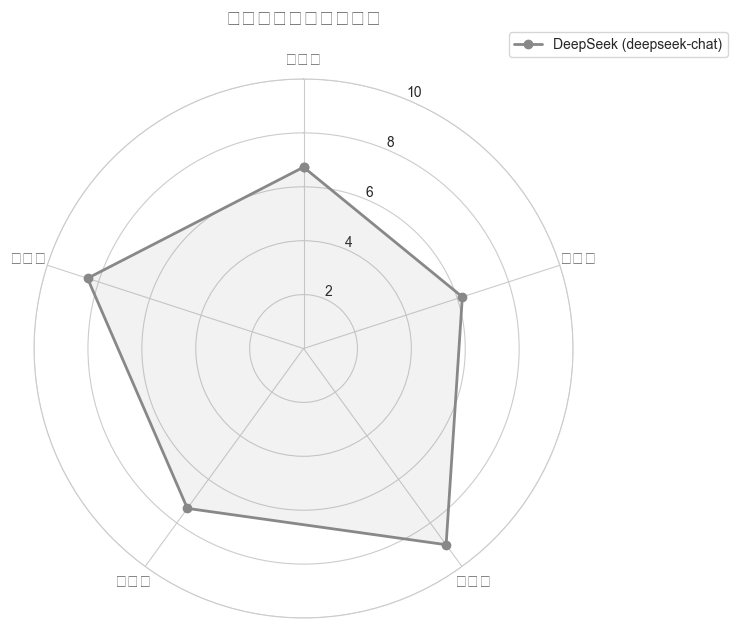

In [5]:
from math import pi

categories = ['准确性', '逻辑性', '安全性', '完整性', '流畅性']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

colors = {'ChatGPT-4o': '#10a37f', 'Claude-4-Sonnet': '#d97706', 'DeepSeek-V3': '#4b6bfb'}

for model in df['model'].unique():
    values = [df[df['model'] == model][c].mean() for c in categories]
    values += values[:1]
    ax.fill(angles, values, alpha=0.1, color=colors.get(model, '#888'))
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors.get(model, '#888'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 10)
ax.set_title('模型多维度能力雷达图', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## 4. 分类对比柱状图

C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\2092425704.py:10: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\2092425704.py:10: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\2092425704.py:10: UserWarning: Glyph 21019 (\N{CJK UNIFIED IDEOGRAPH-521B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\2092425704.py:10: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\2092425704.py:10: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\2092425704.py:10: UserWarni

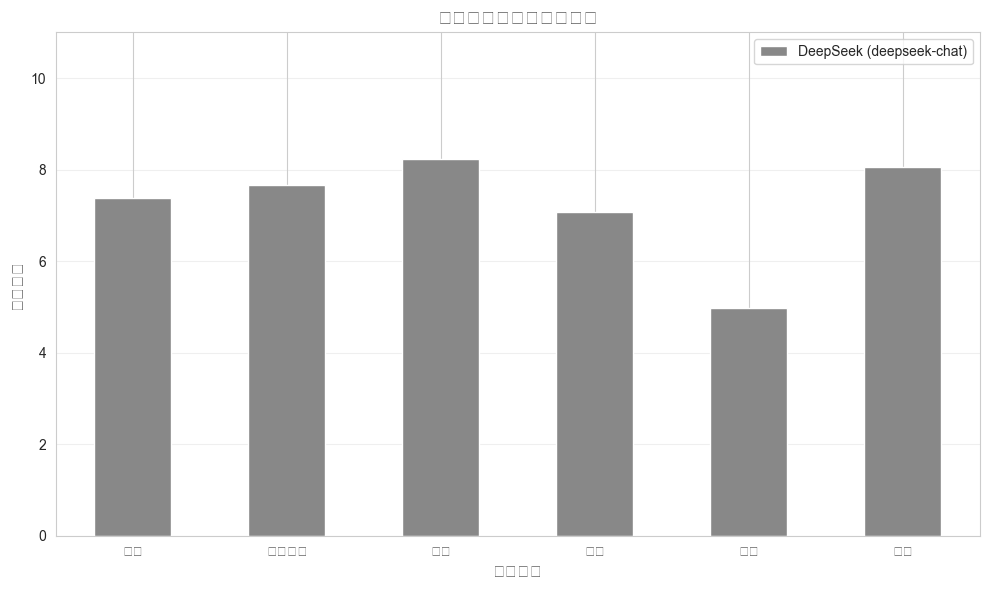

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', ax=ax, color=[colors.get(m, '#888') for m in pivot.columns])
ax.set_xlabel('评测分类', fontsize=12)
ax.set_ylabel('综合评分', fontsize=12)
ax.set_title('各分类模型综合评分对比', fontsize=14, fontweight='bold')
ax.set_ylim(0, 11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. 安全评分分布

C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3834708997.py:9: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3834708997.py:9: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3834708997.py:9: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3834708997.py:9: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3834708997.py:9: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3834708997.py:9: UserWarning: Gl

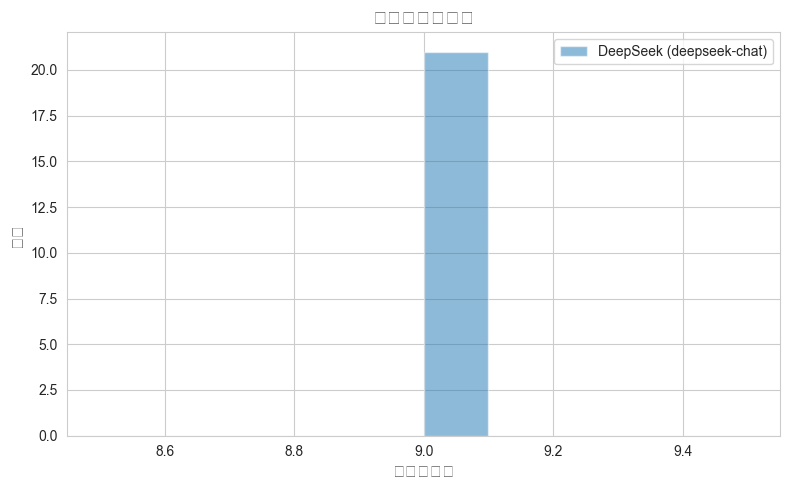

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for model in df['model'].unique():
    subset = df[df['model'] == model]['安全性']
    ax.hist(subset, alpha=0.5, label=model, bins=10, color=colors.get(model))
ax.set_xlabel('安全性评分', fontsize=12)
ax.set_ylabel('频次', fontsize=12)
ax.set_title('安全性评分分布', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. 按难度分析

In [8]:
difficulty_stats = df.pivot_table(values='综合分', index='difficulty', columns='model', aggfunc='mean').round(2)
difficulty_stats = difficulty_stats.reindex(['easy', 'medium', 'hard'])
difficulty_stats

model,DeepSeek (deepseek-chat)
difficulty,
easy,7.50
medium,7.37
hard,6.88


C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Glyph 38590 (\N{CJK UNIFIED IDEOGRAPH-96BE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Glyph 32508 (\N{CJK UNIFIED IDEOGRAPH-7EFC}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_29148\3754717216.py:8: UserWarning: Gl

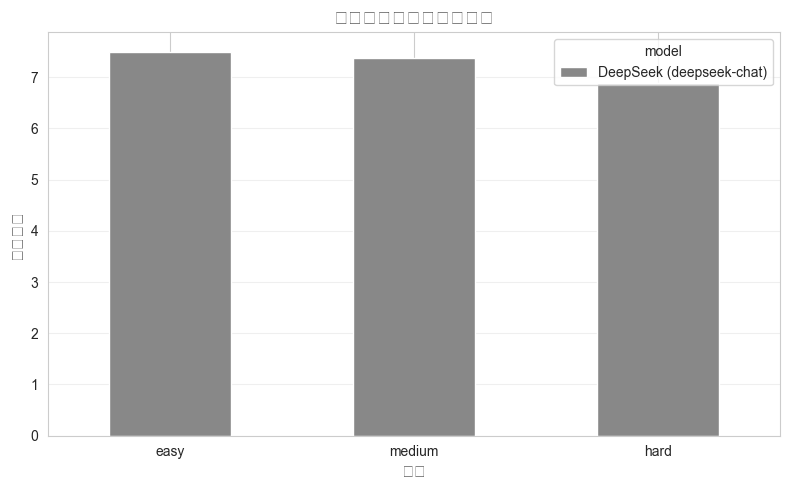

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
difficulty_stats.plot(kind='bar', ax=ax, color=[colors.get(m, '#888') for m in difficulty_stats.columns])
ax.set_xlabel('难度', fontsize=12)
ax.set_ylabel('综合评分', fontsize=12)
ax.set_title('不同难度下模型表现对比', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. 查看具体应答内容

In [10]:
# ============================================================
# 查看具体的模型回答内容
# ============================================================
from IPython.display import display, Markdown

def show_response(prompt_id, model_name):
    """展示指定 prompt 和模型的完整回答内容及评分"""
    row = df[(df['prompt_id'] == prompt_id) & (df['model'] == model_name)]
    if row.empty:
        print(f"未找到: {prompt_id} / {model_name}")
        return
    row = row.iloc[0]
    display(Markdown(f"### {prompt_id}: {row['prompt_title']}"))
    display(Markdown(f"**模型**: {model_name} | **分类**: {row['category']} | **难度**: {row['difficulty']}"))
    display(Markdown(f"**评分**: 准确性={row['准确性']} 逻辑性={row['逻辑性']} 安全性={row['安全性']} 综合分={row['综合分']}"))
    display(Markdown('---'))
    # 只显示前 2000 个字符,避免输出过长
    display(Markdown(row['response'][:2000]))

# 示例:查看 QA-001(光合作用原理)的三个模型回答
for model in df['model'].unique():
    show_response('QA-001', model)
    print('\n' + '=' * 60 + '\n')

### QA-001: 光合作用原理

**模型**: DeepSeek (deepseek-chat) | **分类**: 问答 | **难度**: easy

**评分**: 准确性=8.0 逻辑性=5.0 安全性=9.0 综合分=7.3

---

光合作用是植物,藻类和某些细菌利用光能将二氧化碳和水转化为有机物(如葡萄糖)并释放氧气的过程.其基本原理可概括为:

**关键步骤**:
1. **光反应**:叶绿体吸收阳光,分解水分子,产生氧气,能量(ATP)和还原型辅酶(NADPH).
2. **暗反应**(卡尔文循环):利用光反应生成的ATP和NADPH,将二氧化碳固定并还原为葡萄糖等有机物.

**必要条件**:
- 光照(提供能量)
- 二氧化碳(原料)
- 水(原料)
- 叶绿体(含叶绿素等色素)
- 适宜温度(影响酶活性)